In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [ ]:
df = pd.read_csv(path + "/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
for a in df.columns.tolist():
  print(a)

customerID
gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
Churn


Dimensiones: (7043, 22)
Columnas: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Churn_numeric']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   ob

/tmp/ipython-input-2601836602.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Churn", data=df, palette="Set2")


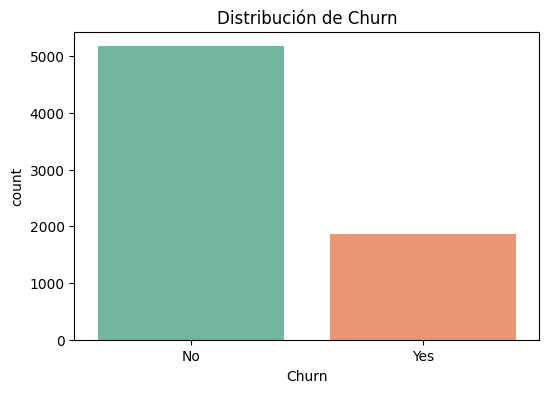


Distribución de Churn (%):
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

Estadísticas descriptivas:
            tenure  MonthlyCharges  TotalCharges
count  7043.000000     7043.000000   7032.000000
mean     32.371149       64.761692   2283.300441
std      24.559481       30.090047   2266.771362
min       0.000000       18.250000     18.800000
25%       9.000000       35.500000    401.450000
50%      29.000000       70.350000   1397.475000
75%      55.000000       89.850000   3794.737500
max      72.000000      118.750000   8684.800000


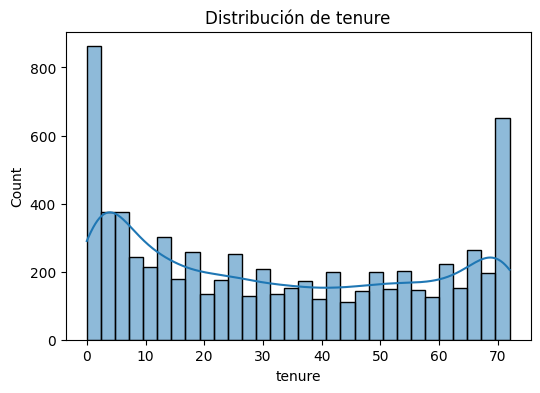

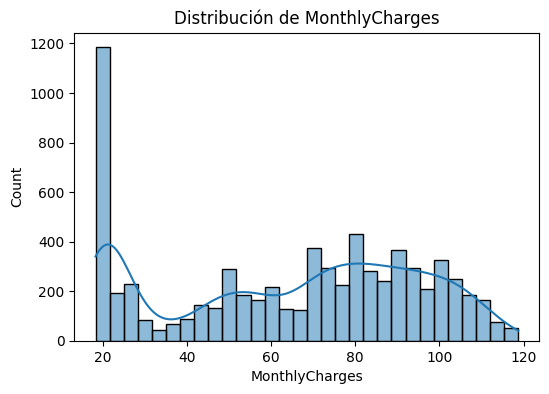

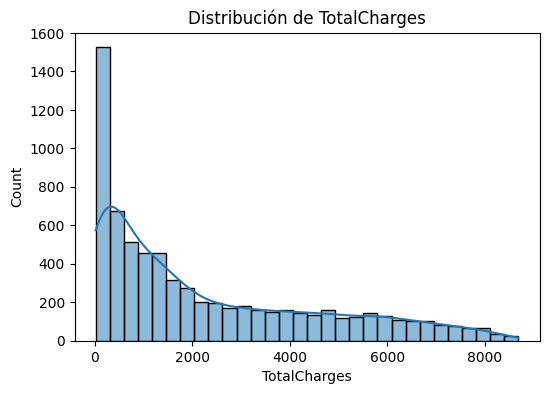

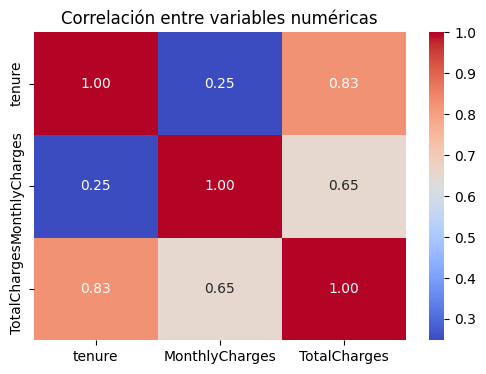

/tmp/ipython-input-2601836602.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn", y=col, data=df, palette="Set1")


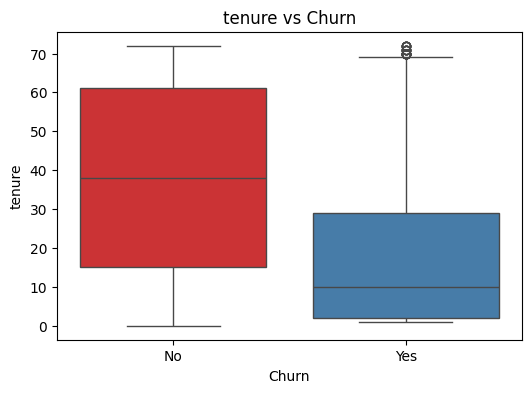

/tmp/ipython-input-2601836602.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn", y=col, data=df, palette="Set1")


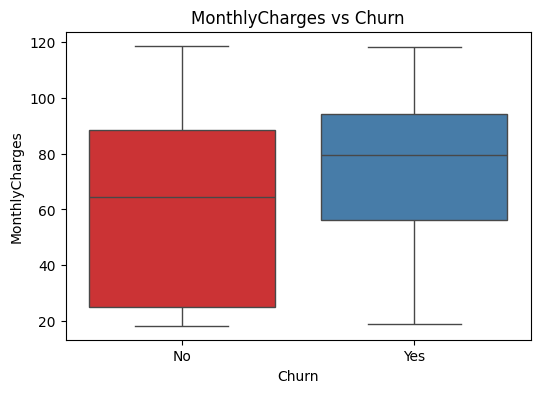

/tmp/ipython-input-2601836602.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn", y=col, data=df, palette="Set1")


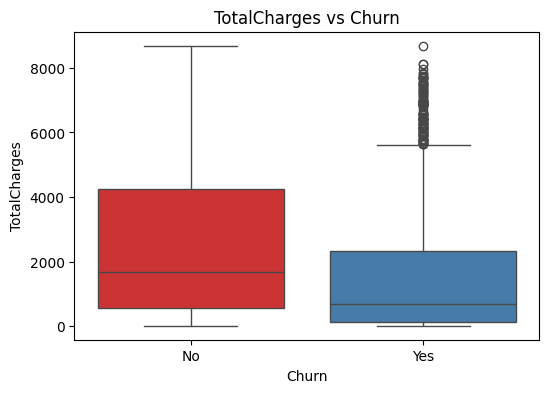

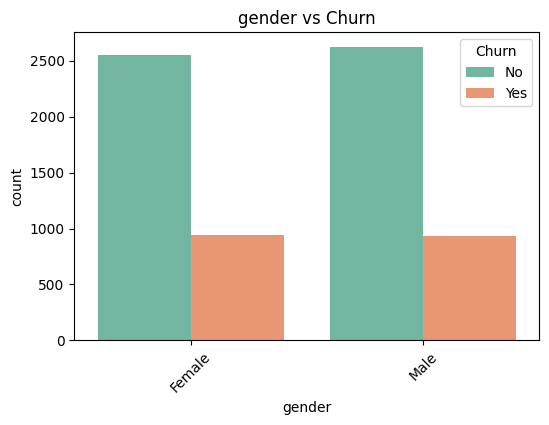

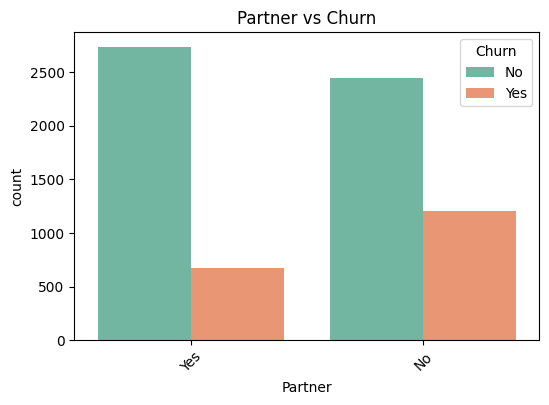

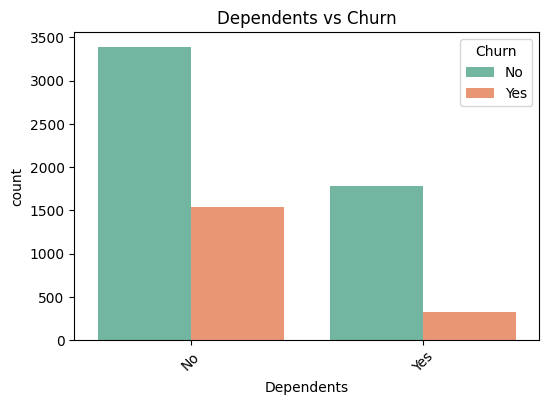

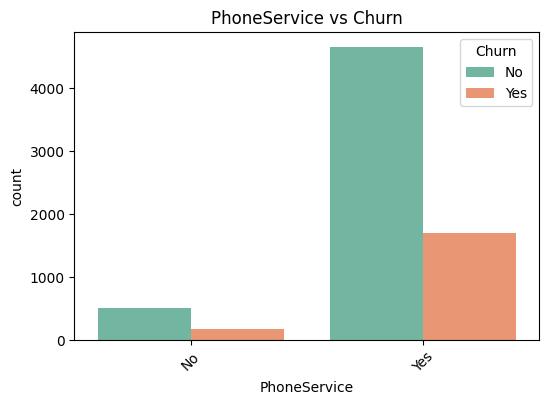

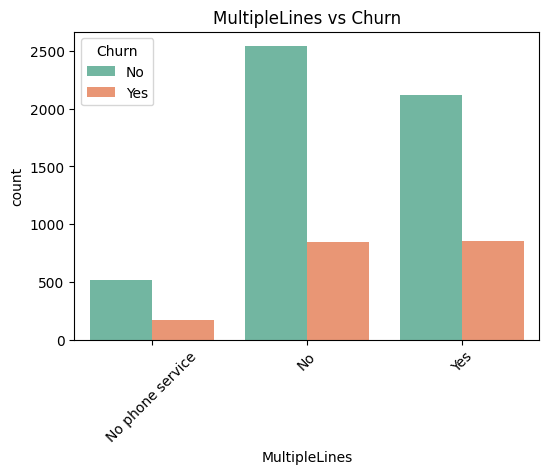

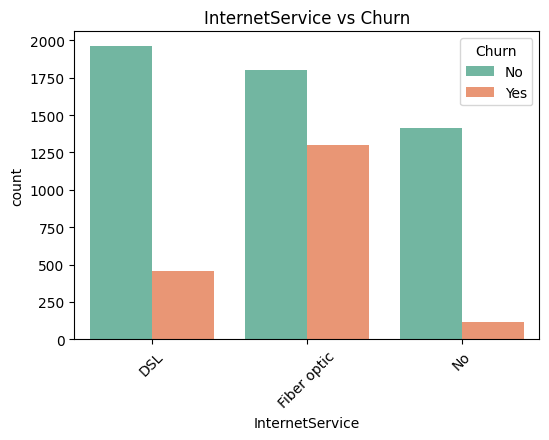

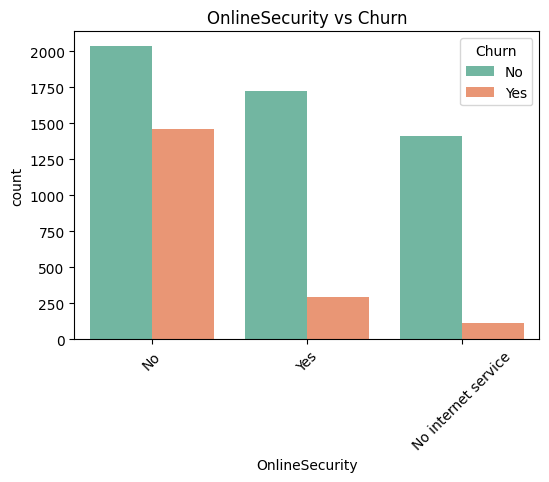

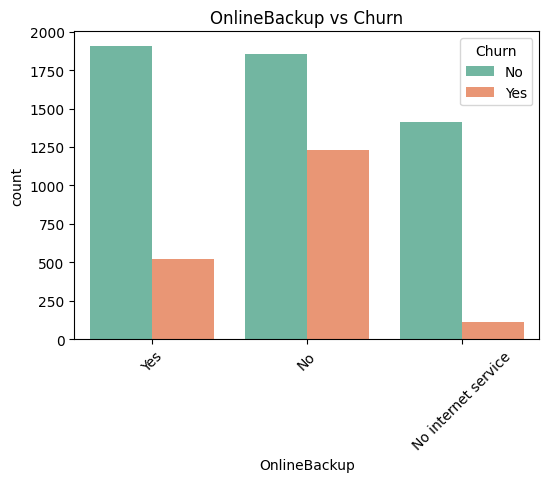

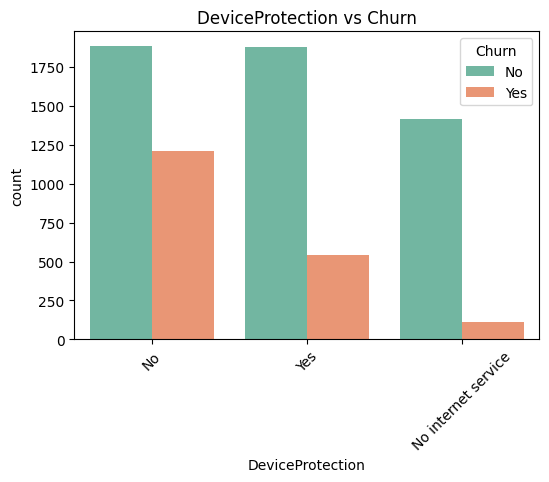

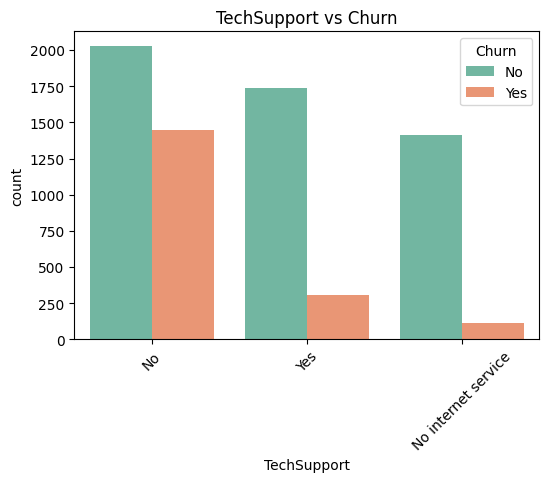

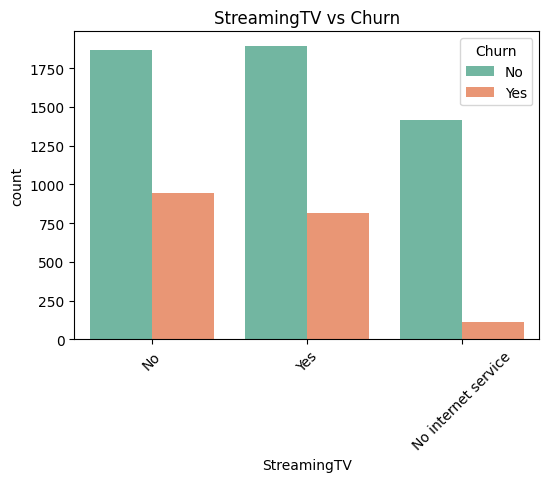

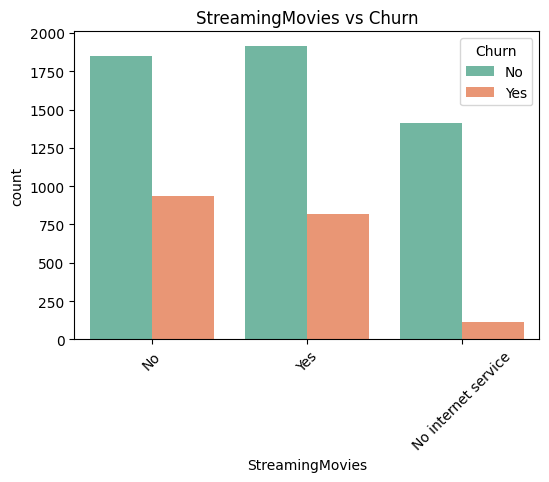

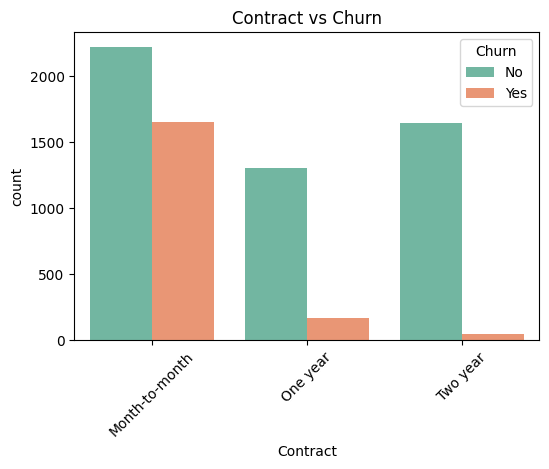

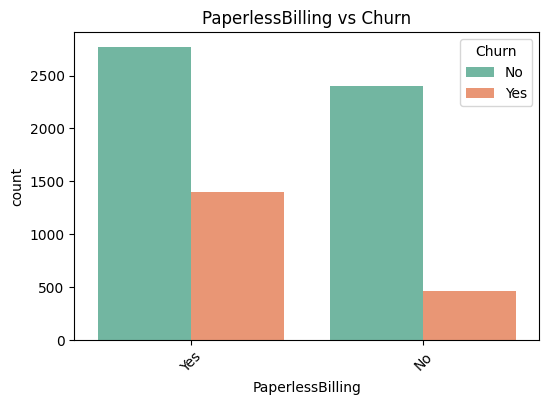

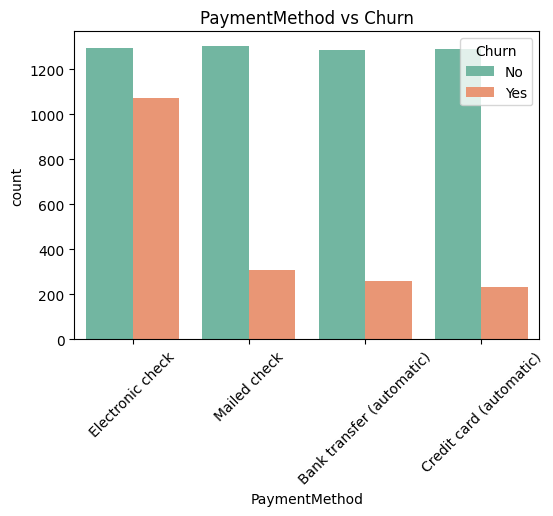

In [7]:
print("Dimensiones:", df.shape)
print("Columnas:", df.columns.tolist())

# Revisar tipos de datos
print("\nInfo:")
print(df.info())

# Valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())

# 4. Limpieza de TotalCharges (viene como string)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("\nValores nulos después de convertir TotalCharges:", df["TotalCharges"].isnull().sum())

# 5. Distribución de la variable objetivo
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df, palette="Set2")
plt.title("Distribución de Churn")
plt.show()

churn_dist = df["Churn"].value_counts(normalize=True) * 100
print("\nDistribución de Churn (%):")
print(churn_dist)

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

print("\nEstadísticas descriptivas:")
print(df[num_cols].describe())

# Histogramas
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribución de {col}")
    plt.show()

# Correlación numérica
plt.figure(figsize=(6,4))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlación entre variables numéricas")
plt.show()

# 7. Relación de numéricas con Churn
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Churn", y=col, data=df, palette="Set1")
    plt.title(f"{col} vs Churn")
    plt.show()

# 8. Variables categóricas y su relación con Churn
cat_cols = df.select_dtypes(include="object").columns.drop(["customerID", "Churn"])

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue="Churn", data=df, palette="Set2")
    plt.title(f"{col} vs Churn")
    plt.xticks(rotation=45)
    plt.show()


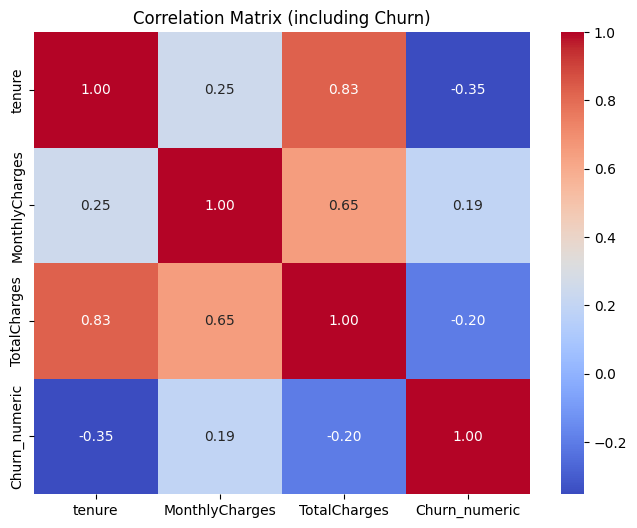

In [ ]:
# Load the data if not already loaded (assuming 'path' is defined in a previous cell)
try:
    df
except NameError:
    df = pd.read_csv(path + "/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Convert 'Churn' column to numerical (1 for Yes, 0 for No)
df['Churn_numeric'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Select only numerical columns, including the new 'Churn_numeric'
num_cols_with_churn = ["tenure", "MonthlyCharges", "TotalCharges", "Churn_numeric"]

# Calculate and display the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols_with_churn].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (including Churn)")
plt.show()

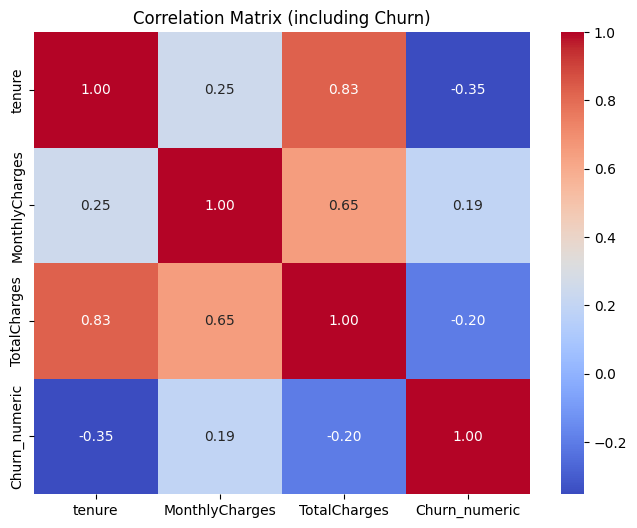

In [ ]:
# Convert 'Churn' column to numerical (1 for Yes, 0 for No)
df['Churn_numeric'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Select only numerical columns, including the new 'Churn_numeric'
num_cols_with_churn = ["tenure", "MonthlyCharges", "TotalCharges", "Churn_numeric"]

# Calculate and display the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols_with_churn].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (including Churn)")
plt.show()

In [10]:
# Check for the number of missing values in the TotalCharges column
print("Number of missing values in TotalCharges before imputation:", df['TotalCharges'].isnull().sum())

# Fill missing values with the median
median_total_charges = df['TotalCharges'].median()
df['TotalCharges'].fillna(median_total_charges, inplace=True)

# Verify that there are no more missing values
print("Number of missing values in TotalCharges after imputation:", df['TotalCharges'].isnull().sum())

Number of missing values in TotalCharges before imputation: 11
Number of missing values in TotalCharges after imputation: 0


/tmp/ipython-input-1616662653.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(median_total_charges, inplace=True)


In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

numerical_predictors = df[["tenure", "MonthlyCharges", "TotalCharges"]]
numerical_predictors = numerical_predictors.dropna()

vif_data = pd.DataFrame()
vif_data["feature"] = numerical_predictors.columns

vif_data["VIF"] = [variance_inflation_factor(numerical_predictors.values, i)
                   for i in range(numerical_predictors.shape[1])]

print("Variance Inflation Factor (VIF) for numerical predictors:")
display(vif_data)

Variance Inflation Factor (VIF) for numerical predictors:


,feature,VIF
0,tenure,6.332432
1,MonthlyCharges,3.361075
2,TotalCharges,8.079181


SVM

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import pandas as pd
from imblearn.over_sampling import SMOTE

# Handle categorical features using one-hot encoding
df_encoded = pd.get_dummies(df.drop('customerID', axis=1), columns=cat_cols, drop_first=True)

# Separate features and target variable
X = df_encoded.drop(["Churn", "Churn_numeric"], axis=1)
y = df_encoded["Churn_numeric"]

# Scale numerical features
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Shape before SMOTE:", X_train.shape)
print("Shape after SMOTE:", X_train_res.shape)


# Initialize and train the SVM model with hyperparameters
svm_model = SVC(kernel='linear', C=1, random_state=42)
svm_model.fit(X_train_res, y_train_res)

# Make predictions
y_pred = svm_model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Shape before SMOTE: (4930, 30)
Shape after SMOTE: (7244, 30)
Accuracy: 0.7524846190250828

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.77      0.82      1552
           1       0.52      0.71      0.61       561

    accuracy                           0.75      2113
   macro avg       0.70      0.74      0.71      2113
weighted avg       0.79      0.75      0.76      2113


Confusion Matrix:
 [[1189  363]
 [ 160  401]]


In [12]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for GridSearchCV
param_grid = {'C': [0.1, 1, 10], # Reduced the range of C for faster testing with multiple kernels
              'kernel': ['linear', 'rbf', 'poly'], # Added rbf and poly kernels
              'gamma': ['scale', 'auto'], # Added gamma for rbf and poly
              'degree': [2, 3]} # Added degree for poly kernel

In [13]:
# Utilizamos cv=5 para la validación cruzada de 5 veces
grid_search = GridSearchCV(SVC(), param_grid, cv=5, scoring='f1')

grid_search.fit(X_train_res, y_train_res)

# Print the best parameters and best score
print("Best parameters found by GridSearchCV:")
print(grid_search.best_params_)
print("Best cross-validation f1 score:")
print(grid_search.best_score_)

Best parameters found by GridSearchCV:
{'C': 10, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-validation f1 score:
0.825008380686325


In [14]:
# Get the best model from GridSearchCV
best_svm_model = grid_search.best_estimator_

# Make predictions on the test set using the best model
y_pred_best = best_svm_model.predict(X_test)

# Evaluate the best model
print("Accuracy with best parameters:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report with best parameters:\n", classification_report(y_test, y_pred_best))
print("\nConfusion Matrix with best parameters:\n", confusion_matrix(y_test, y_pred_best))

Accuracy with best parameters: 0.7539044013251301

Classification Report with best parameters:
               precision    recall  f1-score   support

           0       0.87      0.78      0.82      1552
           1       0.53      0.68      0.60       561

    accuracy                           0.75      2113
   macro avg       0.70      0.73      0.71      2113
weighted avg       0.78      0.75      0.76      2113


Confusion Matrix with best parameters:
 [[1211  341]
 [ 179  382]]


Reduciendo dimensionalidad

In [15]:
# Identify features for NMF (excluding target and ID columns)
nmf_features = df_encoded.drop(["Churn", "Churn_numeric"], axis=1)

# Check if all selected features are non-negative.
# After StandardScaler, some values might be negative.
# Add the minimum value to each column to ensure non-negativity.
# This preserves the relative differences between values.
nmf_features_non_negative = nmf_features.copy()
for col in nmf_features_non_negative.columns:
    min_val = nmf_features_non_negative[col].min()
    if min_val < 0:
        nmf_features_non_negative[col] = nmf_features_non_negative[col] + abs(min_val)

# Verify that minimum values are now non-negative
print("Minimum values of features after ensuring non-negativity:")
print(nmf_features_non_negative.min())

# Create a new DataFrame with the non-negative features
X_nmf = nmf_features_non_negative

Minimum values of features after ensuring non-negativity:
SeniorCitizen                                0
tenure                                       0
MonthlyCharges                           18.25
TotalCharges                              18.8
gender_Male                              False
Partner_Yes                              False
Dependents_Yes                           False
PhoneService_Yes                         False
MultipleLines_No phone service           False
MultipleLines_Yes                        False
InternetService_Fiber optic              False
InternetService_No                       False
OnlineSecurity_No internet service       False
OnlineSecurity_Yes                       False
OnlineBackup_No internet service         False
OnlineBackup_Yes                         False
DeviceProtection_No internet service     False
DeviceProtection_Yes                     False
TechSupport_No internet service          False
TechSupport_Yes                          False
St

In [16]:
from sklearn.decomposition import NMF

# Initialize NMF
# Choose a suitable number of components, e.g., 15
n_components = 15
nmf = NMF(n_components=n_components, random_state=42, init='random', max_iter=200)

# Apply NMF transformation to the non-negative data
X_nmf_transformed = nmf.fit_transform(X_nmf)

# Convert the transformed data back to a DataFrame for easier handling
X_nmf_transformed = pd.DataFrame(X_nmf_transformed, columns=[f'nmf_comp_{i+1}' for i in range(n_components)])

print("Shape of original data for NMF:", X_nmf.shape)
print("Shape of NMF transformed data:", X_nmf_transformed.shape)
display(X_nmf_transformed.head())

Shape of original data for NMF: (7043, 30)
Shape of NMF transformed data: (7043, 15)


,nmf_comp_1,nmf_comp_2,nmf_comp_3,nmf_comp_4,nmf_comp_5,nmf_comp_6,nmf_comp_7,nmf_comp_8,nmf_comp_9,nmf_comp_10,nmf_comp_11,nmf_comp_12,nmf_comp_13,nmf_comp_14,nmf_comp_15
0,0.379427,0.000000,0.000019,0.339195,0.000000,0.109475,0.364359,0.000759,0.000116,0.000000,0.002348,0.000139,0.004859,2.128998,0.028819
1,33.829860,2.318199,0.000000,0.164502,2.632147,0.003433,0.000000,0.000000,0.001796,0.148004,0.000000,5.569973,0.000924,26.172746,0.026503
2,0.340565,0.000000,0.001237,0.567227,0.000000,0.099192,0.000000,0.000000,0.000000,0.134047,0.000000,0.000000,0.003549,2.364678,0.585476
3,35.104249,6.375008,0.000000,0.070793,5.967435,0.002519,0.000000,0.000000,0.000000,0.000000,0.000000,4.195269,0.000000,21.264612,0.000000
4,2.800730,0.000000,0.000211,0.825610,0.000000,0.229065,0.898216,0.000000,0.000531,0.000000,0.005289,0.000000,0.011094,5.489814,0.086794


**Reasoning**:
Split the dimensionally reduced data into training and testing sets using train_test_split.



In [ ]:
from sklearn.model_selection import train_test_split

# Split the NMF transformed data and the target variable
X_train_nmf, X_test_nmf, y_train_nmf, y_test_nmf = train_test_split(
    X_nmf_transformed, y, test_size=0.3, random_state=42, stratify=y
)

# Print the shapes of the resulting sets
print("Shape of X_train_nmf:", X_train_nmf.shape)
print("Shape of X_test_nmf:", X_test_nmf.shape)
print("Shape of y_train_nmf:", y_train_nmf.shape)
print("Shape of y_test_nmf:", y_test_nmf.shape)

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# Suponiendo que 'grid_search.best_params_' del paso anterior está disponible
if 'grid_search' in locals() and hasattr(grid_search, 'best_params_'):
    best_params = grid_search.best_params_
    svm_model_nmf = SVC(**best_params, random_state=42)
    print("Using best parameters from GridSearchCV:", best_params)
else:
    svm_model_nmf = SVC(random_state=42)
    print("Using default SVM parameters.")


# Train the SVM model on the NMF transformed training data
svm_model_nmf.fit(X_train_nmf, y_train_nmf)

# Make predictions on the NMF transformed test data
y_pred_nmf = svm_model_nmf.predict(X_test_nmf)

# Evaluate the model
print("\nAccuracy on NMF transformed data:", accuracy_score(y_test_nmf, y_pred_nmf))
print("\nClassification Report on NMF transformed data:\n", classification_report(y_test_nmf, y_pred_nmf))
print("\nConfusion Matrix on NMF transformed data:\n", confusion_matrix(y_test_nmf, y_pred_nmf))

# Calculate and print F1 score
f1 = f1_score(y_test_nmf, y_pred_nmf)
print(f"\nF1 Score on NMF transformed data: {f1:.4f}")

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# Define the parameter grid for GridSearchCV
# You can adjust the parameter ranges as needed
param_grid_nmf = {'C': [0.1, 1, 10],
                  'kernel': ['linear']}
                  #'gamma': ['scale', 'auto'],
                  #'degree': [2, 3]}

In [ ]:
# Initialize and run GridSearchCV on the NMF transformed training data
# Using f1 scoring as requested
grid_search_nmf = GridSearchCV(SVC(), param_grid_nmf, cv=5, scoring='f1')

grid_search_nmf.fit(X_train_nmf, y_train_nmf)

# Print the best parameters and best f1 score
print("Best parameters found by GridSearchCV on NMF data:")
print(grid_search_nmf.best_params_)
print("Best cross-validation f1 score on NMF data:")
print(grid_search_nmf.best_score_)

In [ ]:
# Get the best model from GridSearchCV
best_svm_model_nmf = grid_search_nmf.best_estimator_

# Make predictions on the NMF transformed test data using the best model
y_pred_best_nmf = best_svm_model_nmf.predict(X_test_nmf)

# Evaluate the best model on NMF transformed data
print("\nEvaluation of the best SVM model on NMF transformed test data:")
print("\nClassification Report:\n", classification_report(y_test_nmf, y_pred_best_nmf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_nmf, y_pred_best_nmf))
print(f"\nF1 Score: {f1_score(y_test_nmf, y_pred_best_nmf):.4f}")